In [30]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Carregamento dos Dados e Estatística Gerais

In [31]:
df = pd.read_csv("data/raw/dataset.csv")
df.head()

,id_registro,texto,canal_origem,data,classe_macro,classe_detalhada
0,1,Erro recorrente no sistema ao tentar acessar d...,sistema,2025-03-08,Problemas Técnicos,Erro de Sistema / Aplicação
1,2,Pedido de integração para sincronização de dados.,email,2025-03-22,Solicitações Operacionais,Integração com Sistemas Externos
2,3,Aguardando posicionamento.,formulario,2025-03-02,Outros,Mensagem Genérica
3,4,O sistema apresentou um erro inesperado ao exe...,chat,2025-03-17,Problemas Técnicos,Erro de Sistema / Aplicação
4,5,Aguardando posicionamento.,chat,2025-03-23,Outros,Mensagem Genérica


In [32]:
# 1200 instâncias

df.shape

(1200, 6)

In [33]:
# valores nulos por coluna (nenhum encontrado)

df.isnull().sum()

id_registro         0
texto               0
canal_origem        0
data                0
classe_macro        0
classe_detalhada    0
dtype: int64

In [34]:
# tipos das colunas (maior parte propriamente texto)

df.dtypes

id_registro          int64
texto               object
canal_origem        object
data                object
classe_macro        object
classe_detalhada    object
dtype: object

# Pré-processamento

In [35]:
# puxando stopwords para removê-las posteriormente

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [36]:
stop_words

{'a',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'estamos',
 'estar',
 'estas',
 'estava',
 'estavam',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéramos',
 'estivéssemos',
 'estou',
 'está',
 'estávamos',
 'estão',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fui',
 'fôramos',
 'fôssemos',
 'haja',
 'hajam',
 'hajamos',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houveram',
 'houverei',
 'houverem',
 'houveremos',
 'houveria',
 'houveriam',
 'houvermos',
 'houverá',
 'houverão',
 'houverí

In [37]:
def limpar_texto(texto: str) -> str:

    ''' 
    Pré-processamento para padronizar e limpar texto.
    removendo fatores como acentos, stopwords e espaços duplicados e colocando tudo para lower.
    Isso ajuda na análise do texto pelos algoritmos e também para tratamentos como remoção de duplicatas
    '''

    if not texto:
        return texto

    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    tokens = texto.split()
    texto = [w for w in tokens if w not in stop_words]
    texto = " ".join(texto)
    
    return texto

In [38]:
# garantindo que todos os valores serão texto, limpando-os e removendo possíveis texto vazios após limpeza

df_processed = df.copy()
df_processed["texto"] = df_processed["texto"].astype(str).fillna("")
df_processed["texto_limpo"] = df_processed["texto"].apply(limpar_texto)
df_processed = df_processed[df_processed["texto_limpo"] != ""].copy()

df_processed = df_processed[["id_registro", "texto", "texto_limpo", "canal_origem", "data", "classe_macro", "classe_detalhada"]]
df_processed.head()

,id_registro,texto,texto_limpo,canal_origem,data,classe_macro,classe_detalhada
0,1,Erro recorrente no sistema ao tentar acessar d...,erro recorrente sistema tentar acessar determi...,sistema,2025-03-08,Problemas Técnicos,Erro de Sistema / Aplicação
1,2,Pedido de integração para sincronização de dados.,pedido integracao sincronizacao dados,email,2025-03-22,Solicitações Operacionais,Integração com Sistemas Externos
2,3,Aguardando posicionamento.,aguardando posicionamento,formulario,2025-03-02,Outros,Mensagem Genérica
3,4,O sistema apresentou um erro inesperado ao exe...,sistema apresentou erro inesperado executar fu...,chat,2025-03-17,Problemas Técnicos,Erro de Sistema / Aplicação
4,5,Aguardando posicionamento.,aguardando posicionamento,chat,2025-03-23,Outros,Mensagem Genérica


In [39]:
# removendo coluna de texto inicial após ver que a limpeza funcionou

df_processed = df_processed.drop(columns=['texto'])

In [40]:
# dropando possíveis duplicatas para evitar fatores como vazamento de informação na divisão de treino e teste (duplicata exata quando rótulos e texto são iguais entre as instâncias)

df_processed = df_processed.drop_duplicates(
    subset=["texto_limpo", "classe_macro", "classe_detalhada"]
).copy()

print(f"Linhas antes: {len(df)}")
print(f"Linhas depois: {len(df_processed)}")

Linhas antes: 1200
Linhas depois: 78


In [41]:
# verificando também se existem duplicatas de apenas texto (texto igual mas rótulos conflitantes)

conflitos =  df_processed.groupby("texto_limpo")[["classe_macro", "classe_detalhada"]].nunique().reset_index()
conflitos = conflitos.loc[(conflitos["classe_macro"] > 1) | (conflitos["classe_detalhada"] > 1)]

print("Quantidade de textos com conflito de rótulo:", len(conflitos))

Quantidade de textos com conflito de rótulo: 0


In [42]:
# visualizando dataframe final

df_processed

,id_registro,texto_limpo,canal_origem,data,classe_macro,classe_detalhada
0,1,erro recorrente sistema tentar acessar determi...,sistema,2025-03-08,Problemas Técnicos,Erro de Sistema / Aplicação
1,2,pedido integracao sincronizacao dados,email,2025-03-22,Solicitações Operacionais,Integração com Sistemas Externos
2,3,aguardando posicionamento,formulario,2025-03-02,Outros,Mensagem Genérica
3,4,sistema apresentou erro inesperado executar fu...,chat,2025-03-17,Problemas Técnicos,Erro de Sistema / Aplicação
5,6,registro automatico sistema,formulario,2025-03-19,Outros,Registro Automático
...,...,...,...,...,...,...
216,217,solicito treinamento equipe,chat,2025-03-28,Solicitações Operacionais,Solicitação de Treinamento
240,241,erro gerar relatorio financeiro pdf csv,chat,2025-03-03,Problemas Técnicos,Erro de Exportação / Relatórios
293,294,necessario capacitacao usuarios sistema,formulario,2025-03-13,Solicitações Operacionais,Solicitação de Treinamento
352,353,valor fatura parece incorreto,formulario,2025-03-05,Financeiro e Cobrança,Dúvidas sobre Fatura / Valores


# Visualizações

## Distribuição de Classes

### Classe Macro

In [43]:
# Quantidade de Classes Macro presentes na base

print(f"Classes Macro ({len(df_processed['classe_macro'].unique())}): {df_processed['classe_macro'].unique()}")


Classes Macro (5): ['Problemas Técnicos' 'Solicitações Operacionais' 'Outros'
 'Financeiro e Cobrança' 'Feedback e Experiência']


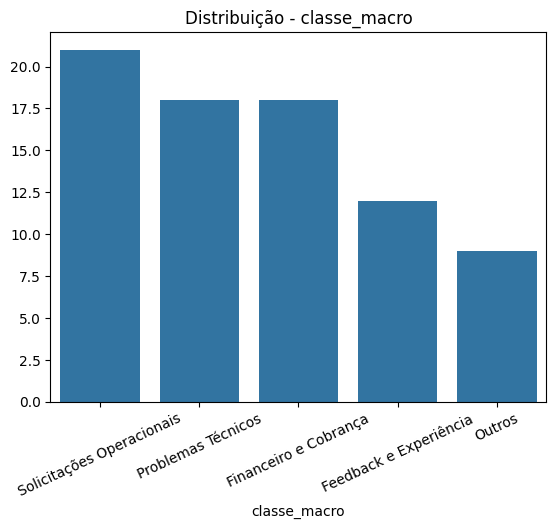

In [44]:
# Distribuição das Classes Macro

macro_counts = df_processed["classe_macro"].value_counts()

sns.barplot(x=macro_counts.index, y=macro_counts.values)
plt.title("Distribuição - classe_macro")
plt.xticks(rotation=25)
plt.show()

Distribuição das classes macro se encontra de certa forma balanceada, com cerca de 10 ~ 20 registros por classe. As classes macro que distoam mais são as de "Feedback e Experiência" e "Outros".

In [45]:
print("\nDistribuição classe_macro:")
print(df_processed["classe_macro"].value_counts(dropna=False))


Distribuição classe_macro:
classe_macro
Solicitações Operacionais    21
Problemas Técnicos           18
Financeiro e Cobrança        18
Feedback e Experiência       12
Outros                        9
Name: count, dtype: int64


### Classe detalhada

In [46]:
# Quantidade de Classes Detalhada presentes na base

print(f"Classes Detalhada ({len(df_processed['classe_detalhada'].unique())}): {df_processed['classe_detalhada'].unique()}")

Classes Detalhada (26): ['Erro de Sistema / Aplicação' 'Integração com Sistemas Externos'
 'Mensagem Genérica' 'Registro Automático'
 'Pagamento Realizado mas Não Compensado' 'Cobrança Indevida / Duplicada'
 'Erro de Exportação / Relatórios' 'Segunda Via de Boleto'
 'Feedback Positivo' 'Juros e Encargos' 'Alteração de Plano / Contrato'
 'Atualização Cadastral' 'Crítica de Usabilidade'
 'Customização de Relatórios' 'Sugestão de Nova Funcionalidade'
 'Reembolso / Estorno' 'Agradecimento Simples' 'Falha de Banco de Dados'
 'Dúvidas sobre Fatura / Valores' 'Problemas de Performance / Lentidão'
 'Sugestão de Melhoria' 'Indisponibilidade / Queda do Serviço'
 'Criação / Gestão de Usuários' 'Reprocessamento / Correção de Dados'
 'Solicitação de Treinamento' 'Erro de Autenticação e Acesso']


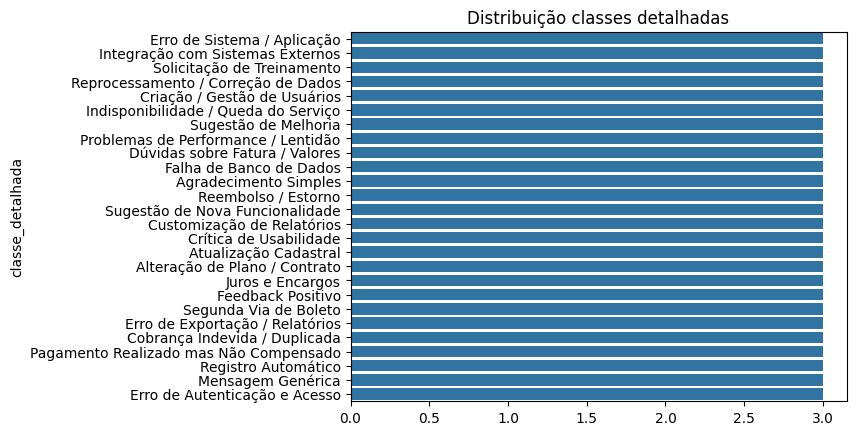

In [47]:
detalhada_counts = df_processed["classe_detalhada"].value_counts()

sns.barplot(x=detalhada_counts.values, y=detalhada_counts.index)
plt.title("Distribuição classes detalhadas")
plt.show()

Distribuição de classe detalhada encontra-se totalmente balanceada, com 3 registros para cada classe detalhada.

In [48]:
print("\nDistribuição classe_detalhada:")
print(df_processed["classe_detalhada"].value_counts(dropna=False))


Distribuição classe_detalhada:
classe_detalhada
Erro de Sistema / Aplicação               3
Integração com Sistemas Externos          3
Solicitação de Treinamento                3
Reprocessamento / Correção de Dados       3
Criação / Gestão de Usuários              3
Indisponibilidade / Queda do Serviço      3
Sugestão de Melhoria                      3
Problemas de Performance / Lentidão       3
Dúvidas sobre Fatura / Valores            3
Falha de Banco de Dados                   3
Agradecimento Simples                     3
Reembolso / Estorno                       3
Sugestão de Nova Funcionalidade           3
Customização de Relatórios                3
Crítica de Usabilidade                    3
Atualização Cadastral                     3
Alteração de Plano / Contrato             3
Juros e Encargos                          3
Feedback Positivo                         3
Segunda Via de Boleto                     3
Erro de Exportação / Relatórios           3
Cobrança Indevida / Duplica

### Classe Macro x Classe Detalhada

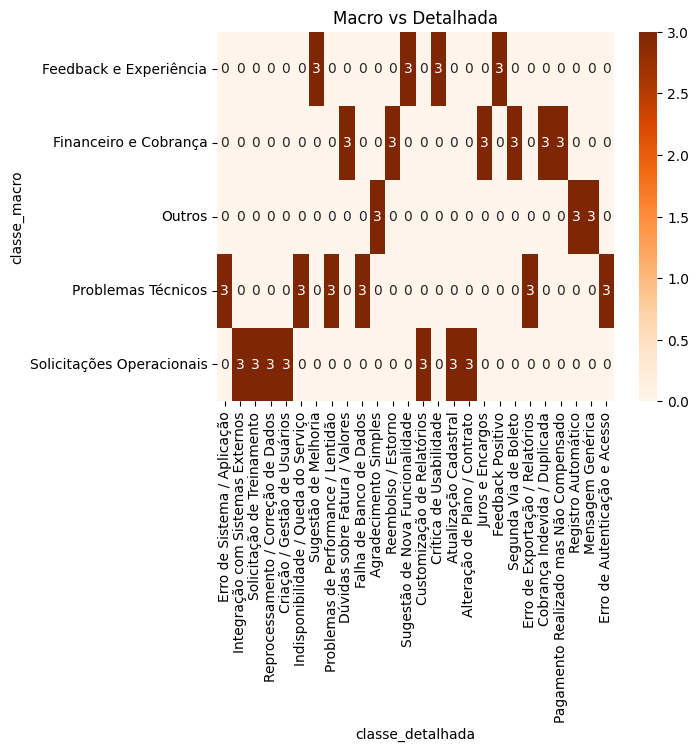

In [49]:
# Distribuição de Classe Detalhada por Macro (confirmando os valores vistos anteriormente)

top_detalhadas = df_processed["classe_detalhada"].value_counts().index

ct = pd.crosstab(df_processed["classe_macro"], df_processed["classe_detalhada"])[top_detalhadas]

sns.heatmap(ct, annot=True, fmt="d", cmap="Oranges")
plt.title("Macro vs Detalhada")
plt.xticks(rotation=90)
plt.show()

## Análise por Canal

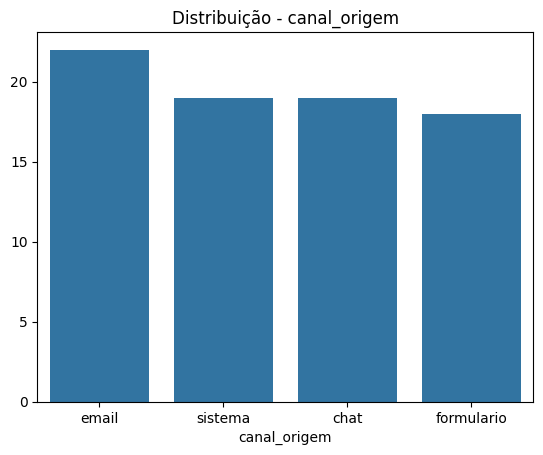

In [50]:
# Distribuição de registros por canal de origem de comunicação

canal_counts = df_processed["canal_origem"].value_counts()

sns.barplot(x=canal_counts.index, y=canal_counts.values)
plt.title("Distribuição - canal_origem")
plt.show()

### Canal de Origem x Classe Macro

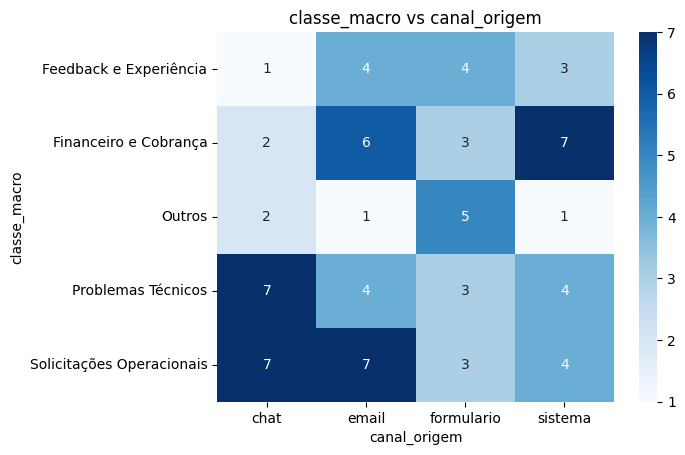

In [51]:
# Tabela cruzada entre classe macro e canal de origem

ct_macro_origem = pd.crosstab(df_processed["classe_macro"], df_processed["canal_origem"])

sns.heatmap(ct_macro_origem, annot=True, fmt="d", cmap="Blues")
plt.title("classe_macro vs canal_origem")
plt.show()

- Percebe-se uma certa tendência de assuntos voltados a "Financeiro e Cobrança" serem tratados por e-mail e sistema, o que pode indicar a prefêrencia de assuntos mais formais serem priorizados por esses tipos de canais (o que é compatível pela menor preferência pelo canal de chat). 
- "Problemas Técnicos" são mais direcionados ao canal de chat.
- "Solicitações Operacionais" apresentam tendência por chat e e-mail.

### Canal de Origem x Classe Detalhada

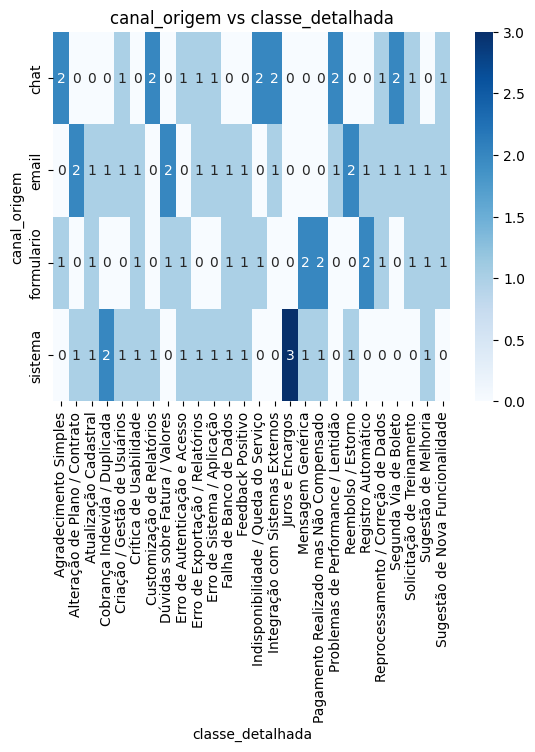

In [52]:
ct = pd.crosstab(df_processed["canal_origem"], df_processed["classe_detalhada"])

sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("canal_origem vs classe_detalhada")
plt.xticks(rotation=90)
plt.show()

amostragem muito baixa não permite tirar muitos insights nesse nível de classe detalhada por canal de origem.

**Conclusão final: O canal de origem pode estar relacionado ao tom da conversa e assunto que ela trata, surgindo a possibilidade de ajudar na classificação das classes macro ao menos.**

## Análise Temporal

In [53]:
# Adicionando features temporais para auxiliar nas visualizações e análises

df["data"] = pd.to_datetime(df["data"], errors="coerce")
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["mes_ano"] = df["data"].dt.to_period("M").astype(str)
df["dia_semana"] = df["data"].dt.day_name()

In [54]:
df.head()

,id_registro,texto,canal_origem,data,classe_macro,classe_detalhada,ano,mes,mes_ano,dia_semana
0,1,Erro recorrente no sistema ao tentar acessar d...,sistema,2025-03-08,Problemas Técnicos,Erro de Sistema / Aplicação,2025,3,2025-03,Saturday
1,2,Pedido de integração para sincronização de dados.,email,2025-03-22,Solicitações Operacionais,Integração com Sistemas Externos,2025,3,2025-03,Saturday
2,3,Aguardando posicionamento.,formulario,2025-03-02,Outros,Mensagem Genérica,2025,3,2025-03,Sunday
3,4,O sistema apresentou um erro inesperado ao exe...,chat,2025-03-17,Problemas Técnicos,Erro de Sistema / Aplicação,2025,3,2025-03,Monday
4,5,Aguardando posicionamento.,chat,2025-03-23,Outros,Mensagem Genérica,2025,3,2025-03,Sunday


### Evolução por mês/ano

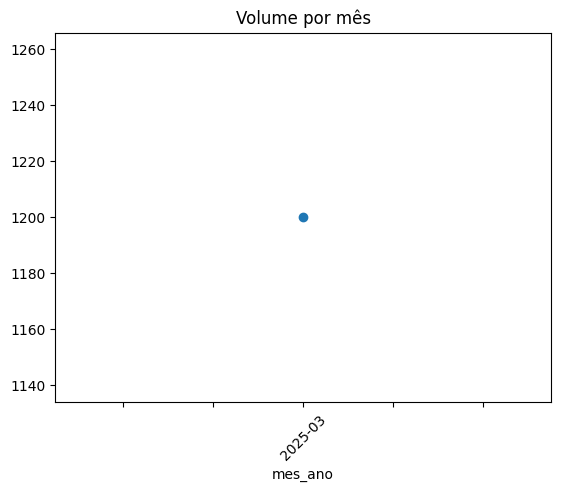

In [55]:
# Evolução de quantidade de mensagens por mês/ano

volume_mes = df.groupby("mes_ano").size()
volume_mes.plot(marker="o")
plt.title("Volume por mês")
plt.xticks(rotation=45)
plt.show()

verifica-se que todas as mensagens são de março de 2025. Assim, pode-se remover as features criadas de "mes", "ano" e "mes_ano".

In [56]:
# Removendo as features irrelevantes

df = df[['id_registro', 'texto', 'canal_origem', 'data', 'dia_semana' ,'classe_macro', 'classe_detalhada']]

In [57]:
df.head()

,id_registro,texto,canal_origem,data,dia_semana,classe_macro,classe_detalhada
0,1,Erro recorrente no sistema ao tentar acessar d...,sistema,2025-03-08,Saturday,Problemas Técnicos,Erro de Sistema / Aplicação
1,2,Pedido de integração para sincronização de dados.,email,2025-03-22,Saturday,Solicitações Operacionais,Integração com Sistemas Externos
2,3,Aguardando posicionamento.,formulario,2025-03-02,Sunday,Outros,Mensagem Genérica
3,4,O sistema apresentou um erro inesperado ao exe...,chat,2025-03-17,Monday,Problemas Técnicos,Erro de Sistema / Aplicação
4,5,Aguardando posicionamento.,chat,2025-03-23,Sunday,Outros,Mensagem Genérica


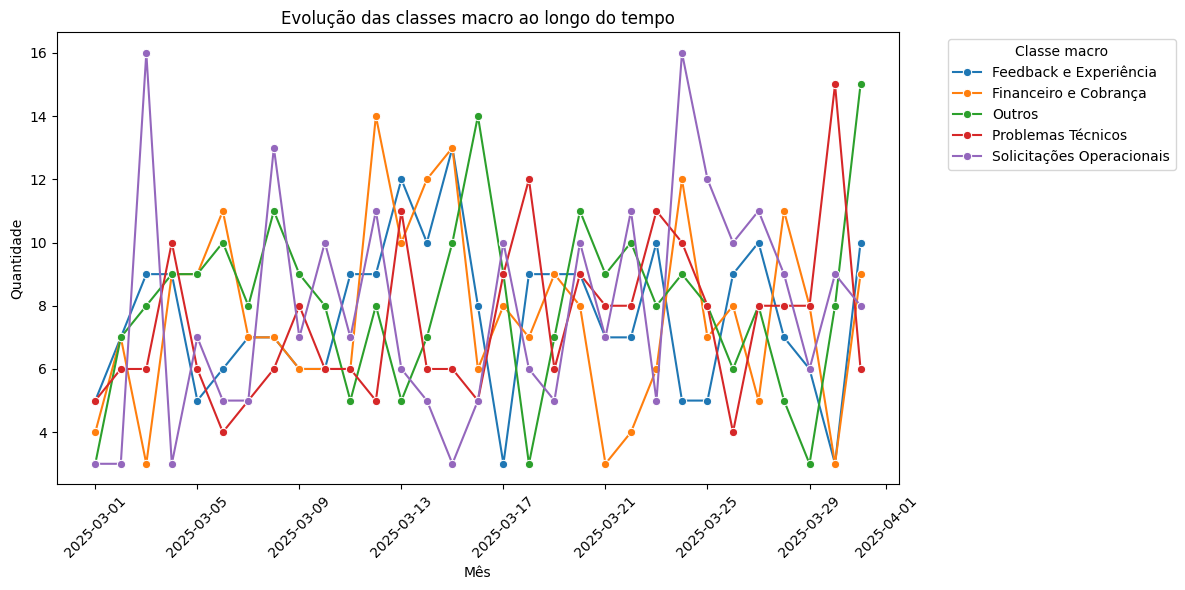

In [58]:
# Evolução da quantidade de mensagens ao longo do mês por classe macro

df_time_macro = df.groupby(["data", "classe_macro"]).size().reset_index(name="qtd")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_time_macro,
    x="data",
    y="qtd",
    hue="classe_macro",
    marker="o"
)

plt.title("Evolução das classes macro ao longo do tempo")
plt.xlabel("Mês")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)
plt.legend(title="Classe macro", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### Análise por dia da semana

In [59]:
# Mapeando nomes dos dias da semana para português para manter padrão 

semana_traduzido = {
    "Monday": "Segunda-feira",
    "Tuesday": "Terça-feira",
    "Wednesday": "Quarta-feira",
    "Thursday": "Quinta-feira",
    "Friday": "Sexta-feira",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}
df['dia_semana'] = df['dia_semana'].map(semana_traduzido)

In [60]:
df.head()

,id_registro,texto,canal_origem,data,dia_semana,classe_macro,classe_detalhada
0,1,Erro recorrente no sistema ao tentar acessar d...,sistema,2025-03-08,Sábado,Problemas Técnicos,Erro de Sistema / Aplicação
1,2,Pedido de integração para sincronização de dados.,email,2025-03-22,Sábado,Solicitações Operacionais,Integração com Sistemas Externos
2,3,Aguardando posicionamento.,formulario,2025-03-02,Domingo,Outros,Mensagem Genérica
3,4,O sistema apresentou um erro inesperado ao exe...,chat,2025-03-17,Segunda-feira,Problemas Técnicos,Erro de Sistema / Aplicação
4,5,Aguardando posicionamento.,chat,2025-03-23,Domingo,Outros,Mensagem Genérica


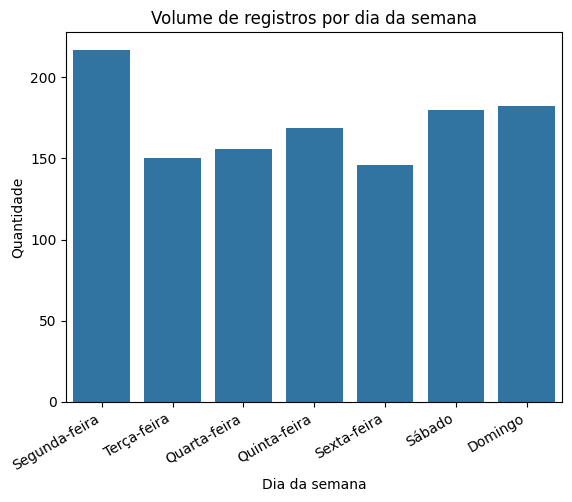

In [61]:
# Observando a quantidade de comunicações feitas por dia da semana

ordem_semana = [
    "Segunda-feira","Terça-feira","Quarta-feira",
    "Quinta-feira","Sexta-feira","Sábado","Domingo"
]

counts_dia = df["dia_semana"].value_counts().reindex(ordem_semana)

sns.barplot(x=counts_dia.index, y=counts_dia.values)
plt.title("Volume de registros por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade")
plt.xticks(rotation=30, ha="right")
plt.show()

- Observa-se que o dia de segunda-feira é o que possui maior quantidade comunicações feitas.

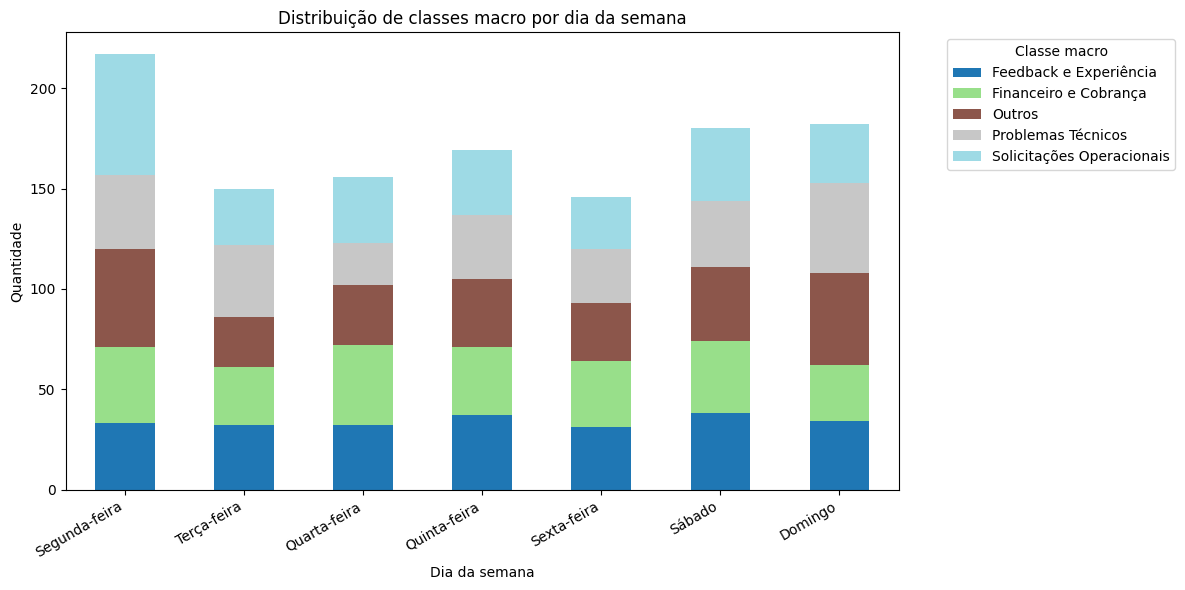

In [62]:
# Visualizando a quantidade de classes macro por dia da semana

ct_macro_dia = pd.crosstab(df["dia_semana"], df["classe_macro"]).reindex(ordem_semana)

plt.figure(figsize=(12, 6))

ct_macro_dia.plot(
    kind="bar",
    stacked=True,
    colormap="tab20",
    ax=plt.gca()
)

plt.title("Distribuição de classes macro por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade")

plt.xticks(rotation=30, ha="right")
plt.legend(title="Classe macro", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

- Vê-se que na segunda-feira a maior parte das comunicações é relativa a solicitações operacionais, o que está de acordo com o começo de uma semana de trabalho.
- O volume de mensagens no resto da semana está bem distribuído.

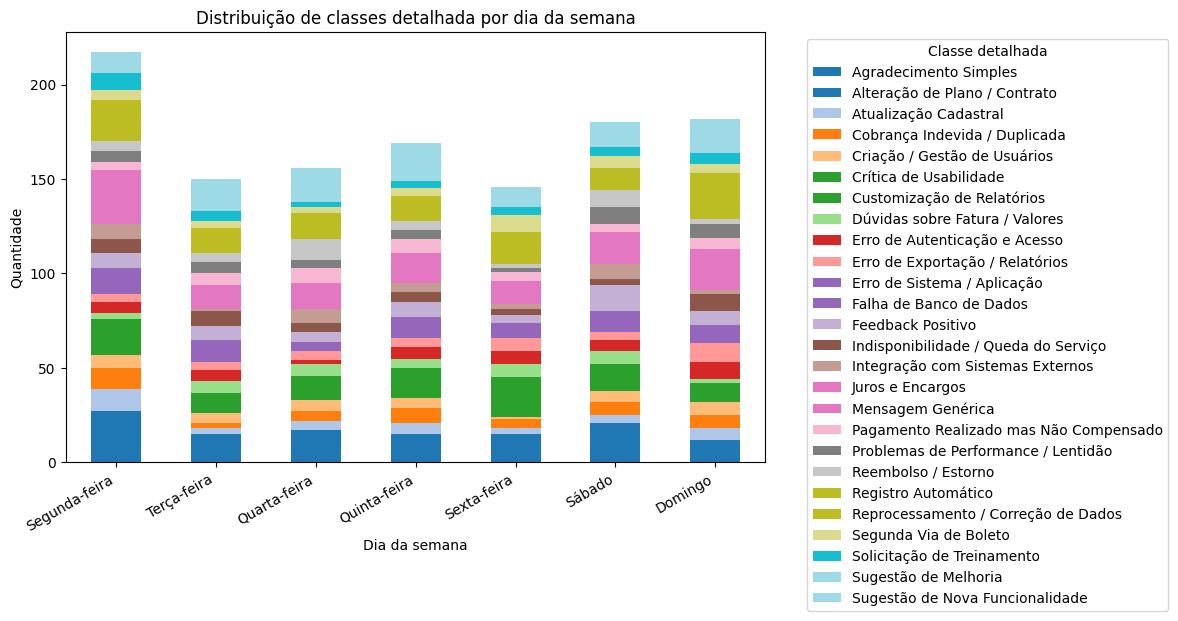

In [63]:
# Visualizando a quantidade de classes detalhada por dia da semana

ct_macro_dia = pd.crosstab(df["dia_semana"], df["classe_detalhada"]).reindex(ordem_semana)

plt.figure(figsize=(12, 6))

ct_macro_dia.plot(
    kind="bar",
    stacked=True,
    colormap="tab20",
    ax=plt.gca()
)

plt.title("Distribuição de classes detalhada por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade")

plt.xticks(rotation=30, ha="right")
plt.legend(title="Classe detalhada", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

**Conclusão: O dia da semana não traz muita informação relevante sobre o conteúdo da mensagem, sendo talvez melhor desconsiderar essa feature. O momento do mês também, onde certos períodos possuem pequenos picos, mas com a distribuição continuando bem homogênea.**

## Análise Textual

### Análise por Tamanho do Texto

In [64]:
# Adicionando features de tamanho do texto e quantidade de palavras que podem ajudar na classificação da mensagem

df_processed["texto_limpo"] = df_processed["texto_limpo"].astype(str)
df_processed["tamanho_texto"] = df_processed["texto_limpo"].apply(len)
df_processed["qntd_palavras_texto"] = df_processed["texto_limpo"].apply(lambda x: len(x.split()))

df_processed[["tamanho_texto", "qntd_palavras_texto"]].describe()

,tamanho_texto,qntd_palavras_texto
count,78.000000,78.000000
mean,35.500000,4.217949
std,11.471874,1.392442
min,14.000000,2.000000
25%,27.250000,3.000000
50%,35.000000,4.000000
75%,40.000000,5.000000
max,78.000000,10.000000


In [65]:
df_processed.head()

,id_registro,texto_limpo,canal_origem,data,classe_macro,classe_detalhada,tamanho_texto,qntd_palavras_texto
0,1,erro recorrente sistema tentar acessar determi...,sistema,2025-03-08,Problemas Técnicos,Erro de Sistema / Aplicação,67,7
1,2,pedido integracao sincronizacao dados,email,2025-03-22,Solicitações Operacionais,Integração com Sistemas Externos,37,4
2,3,aguardando posicionamento,formulario,2025-03-02,Outros,Mensagem Genérica,25,2
3,4,sistema apresentou erro inesperado executar fu...,chat,2025-03-17,Problemas Técnicos,Erro de Sistema / Aplicação,69,7
5,6,registro automatico sistema,formulario,2025-03-19,Outros,Registro Automático,27,3


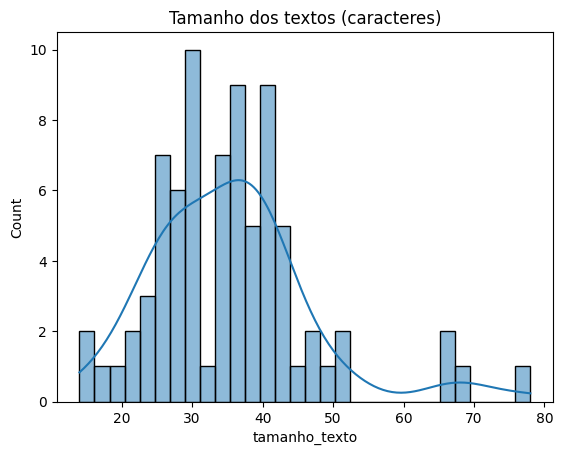

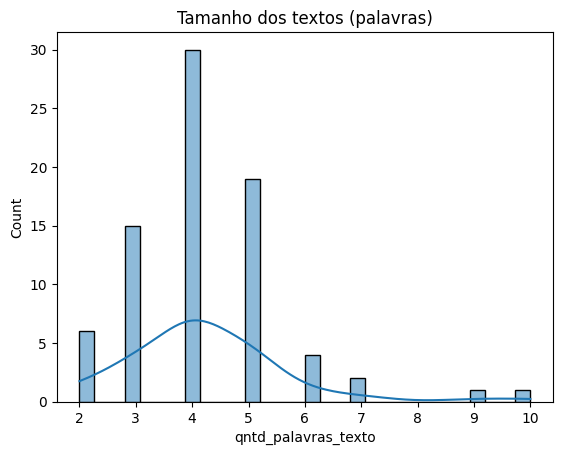

In [66]:
sns.histplot(df_processed["tamanho_texto"], bins=30, kde=True)
plt.title("Tamanho dos textos (caracteres)")
plt.show()

sns.histplot(df_processed["qntd_palavras_texto"], bins=30, kde=True)
plt.title("Tamanho dos textos (palavras)")
plt.show()

Percebe-se que a maioria das mensagens é de menor conteúdo e quantidade palavras.

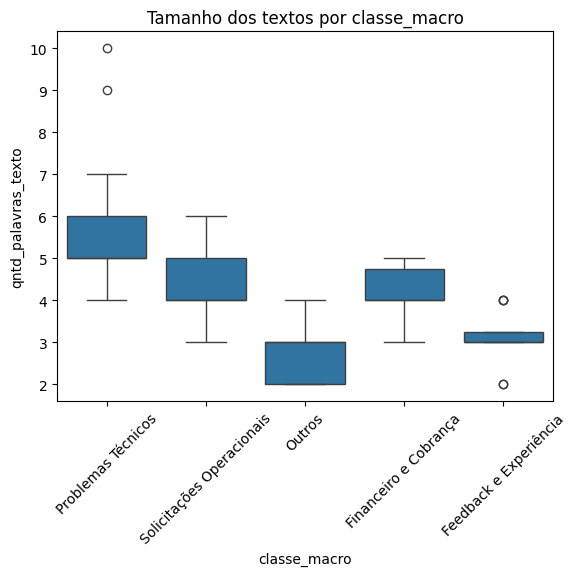

In [67]:
# Visualizando classes macro por quantidade de palavras

sns.boxplot(data=df_processed, x="classe_macro", y="qntd_palavras_texto")
plt.title("Tamanho dos textos por classe_macro")
plt.xticks(rotation=45)
plt.show()

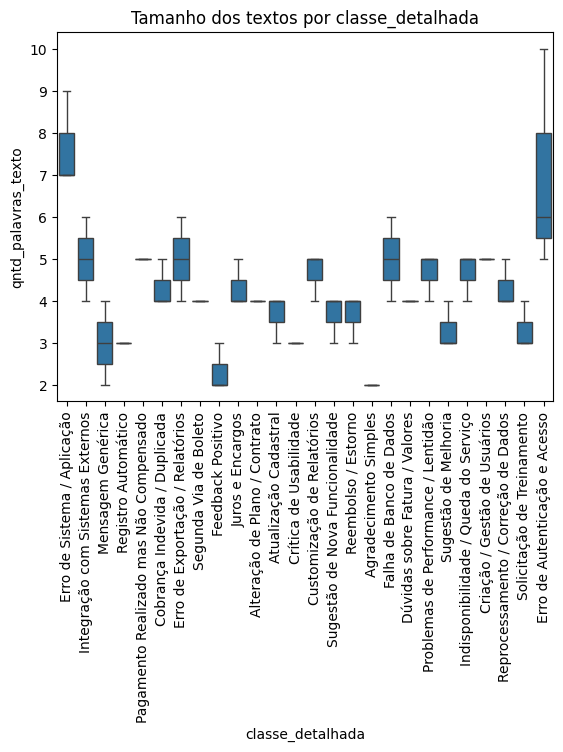

In [68]:
# Visualizando classes detalhada por quantidade de palavras

sns.boxplot(data=df_processed, x="classe_detalhada", y="qntd_palavras_texto")
plt.title("Tamanho dos textos por classe_detalhada")
plt.xticks(rotation=90)
plt.show()

Percebe-se que a quantidade de palavras pode ter relação com a classe macro e detalhada. Texto mais longos parecem estar mais relacionados a "Problemas Técnicos", como "Erro de Sistema/Aplicação" e "Erro de Autenticação e Acesso". Já mensagens mais curtas aparentam estar mais relacionadas às classes "Outros" e "Feedback e Experiência" e suas classes detalhadas, como "Sugestão de Nova Funcionalidade".

### Frequência e Nuvem de Palavras

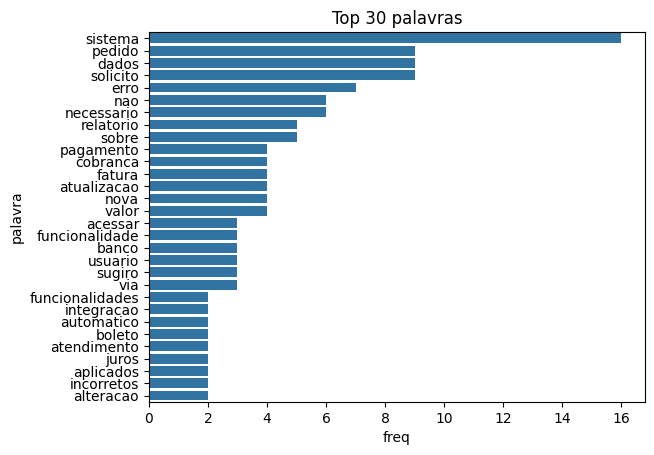

In [69]:
# Definindo e removendo stopwords do texto para limpar e melhorar a visualização de frequência e nuvem de palavras

words = " ".join(df_processed["texto_limpo"]).split()
words = [w for w in words]

freq = Counter(words)

top_words = pd.DataFrame(freq.most_common(30), columns=["palavra", "freq"])

sns.barplot(data=top_words, x="freq", y="palavra")
plt.title("Top 30 palavras")
plt.show()

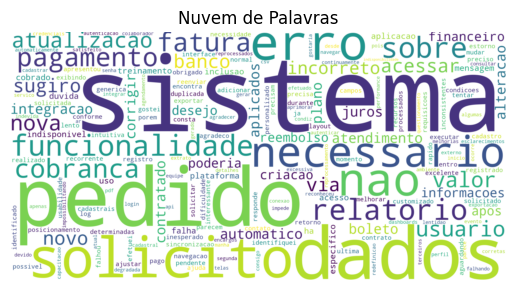

In [70]:
# Nuvem de palavras sem collocation

wc = WordCloud(
    width=2400,
    height=1200,
    background_color="white",
    collocations=False
).generate(" ".join(words))

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras")
plt.show()

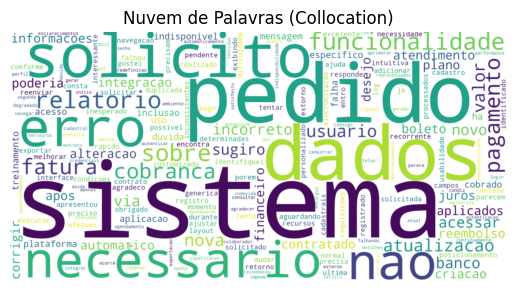

In [71]:
# Nuvem de palavras sem collocation

wc = WordCloud(
    width=2400,
    height=1200,
    background_color="white",
    collocations=True
).generate(" ".join(words))

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras (Collocation)")
plt.show()

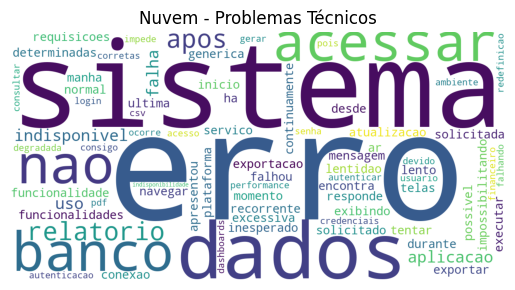

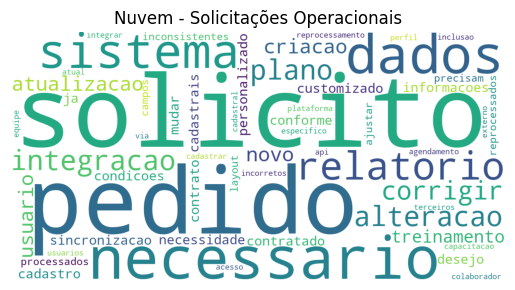

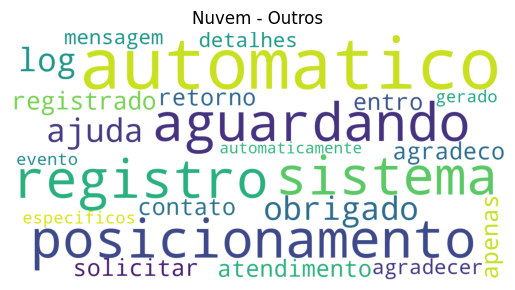

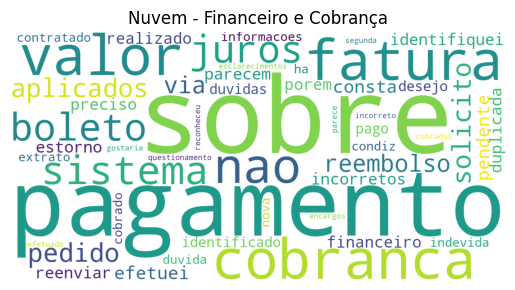

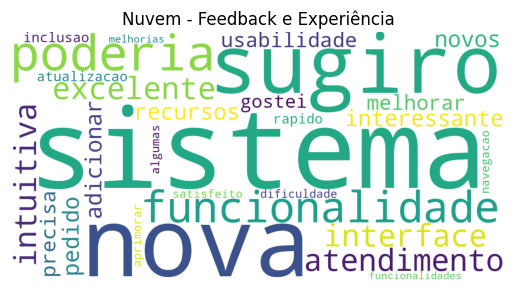

In [73]:
# Nuvem de palavras por classe macro

for classe in df_processed["classe_macro"].unique():
    subset = df_processed[df_processed["classe_macro"] == classe]

    words = " ".join(subset["texto_limpo"]).split()

    freq = Counter(words)

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        collocations=False
    ).generate_from_frequencies(freq)

    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Nuvem - {classe}")
    plt.show()

Pode-se perceber uma forte relação de algumas palavras com a classe macro:

- Problemas Técnicos: Acessar, sistema, erro
- Solicitações Operacionais: Pedido, necessário, solicito
- Outros: (palavras mais espassas, típico de categoria mais genérica)
- Financeiro e Cobrança: Fatura, pagamento, cobrança
- Feedback e Experiência: Sistema, funcionalidade, sugiro

In [75]:
# salvando dataframe pré processado para utilizar no treinamento

df_processed.to_csv('data\processed\dataset.csv')